# Exploratory Data Analysis

## 0. Import Packages

In [12]:
#basic
import numpy as np
import pandas as pd
import os
import math

#plot
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm
import shap
from scipy.spatial import ConvexHull
import statsmodels.formula.api as smf

#model training
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error, median_absolute_error
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib

#optimizer
import optuna
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
    plot_parallel_coordinate
)
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical

#regressors
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

## 1. Import Dataset

In [13]:
#get user name
user_name = os.getlogin()
print(user_name)

Yushu gong


In [14]:
#reading the local csv
if user_name == 'Yushu gong':
    df = pd.read_csv("C:\\Users\\Yushu gong\\Desktop\\Albert School\\ML-SL\\Final-Project\\company_esg_financial_dataset.csv")
else:
    df = pd.read_csv(r"/Users/vivianhung/Documents/git_project/Machine-Learning-Project/data/company_esg_financial_dataset.csv")

In [15]:
df.head(10)

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8
5,1,Company_1,Retail,Latin America,2020,567.5,6.0,384.1,2.3,55.7,65.1,28.5,73.5,42245.4,21122.7,84490.9
6,1,Company_1,Retail,Latin America,2021,604.2,5.2,479.3,6.5,55.6,66.8,25.5,74.6,44263.8,22131.9,88527.7
7,1,Company_1,Retail,Latin America,2022,593.2,4.2,248.4,-1.8,57.7,69.0,27.1,76.9,42536.3,21268.2,85072.6
8,1,Company_1,Retail,Latin America,2023,636.7,5.3,373.9,7.3,57.8,68.3,27.0,78.1,45956.3,22978.2,91912.6
9,1,Company_1,Retail,Latin America,2024,687.0,4.6,460.1,7.9,58.5,68.9,29.9,76.8,49289.1,24644.5,98578.1


In [16]:
df.columns

Index(['CompanyID', 'CompanyName', 'Industry', 'Region', 'Year', 'Revenue',
       'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall',
       'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions',
       'WaterUsage', 'EnergyConsumption'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         10000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyConsumption  11000 non-null  float64
dtypes: float64(11), int64(

In [18]:
# the data set missing the one year of growthrate data
df_missing = df[df.isnull().any(axis=1)]
print(df_missing.shape)
df_missing.head(5)

(1000, 16)


,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
11,2,Company_2,Retail,Asia,2015,2934.8,-2.9,1803.1,NaN,59.9,61.1,48.6,69.8,226554.2,113277.1,453108.3
22,3,Company_3,Transportation,Latin America,2015,259.7,5.9,140.2,NaN,25.5,3.3,41.6,31.5,183314.5,30552.4,611048.2
33,4,Company_4,Technology,Africa,2015,5036.7,21.2,23192.4,NaN,54.2,97.6,46.2,18.9,130146.6,78087.9,260293.2
44,5,Company_5,Finance,Middle East,2015,2720.9,16.1,3884.5,NaN,43.5,71.9,19.1,39.4,37894.7,18947.3,94736.7


In [19]:
#checking the unique value and time deminsion
print('The dataset contains', df['Year'].nunique(), 'years data')
print('The numbers of company in this dataset is', df['CompanyID'].nunique())

The dataset contains 11 years data
The numbers of company in this dataset is 1000


In [20]:
#for plotting and training we take year 2016-2025 for the complete set of data be used
df_all = df.sort_values(by=['CompanyID', 'Year']).copy()
print("Before dropping the 2015's, we have the df shape as", df_all.shape)

df_final = df_all.dropna().reset_index(drop=True)
print("After dropping, we got the df shape as", df_final.shape)

Before dropping the 2015's, we have the df shape as (11000, 16)
After dropping, we got the df shape as (10000, 16)


## 2. EDA

### 2.1 ESG data general view

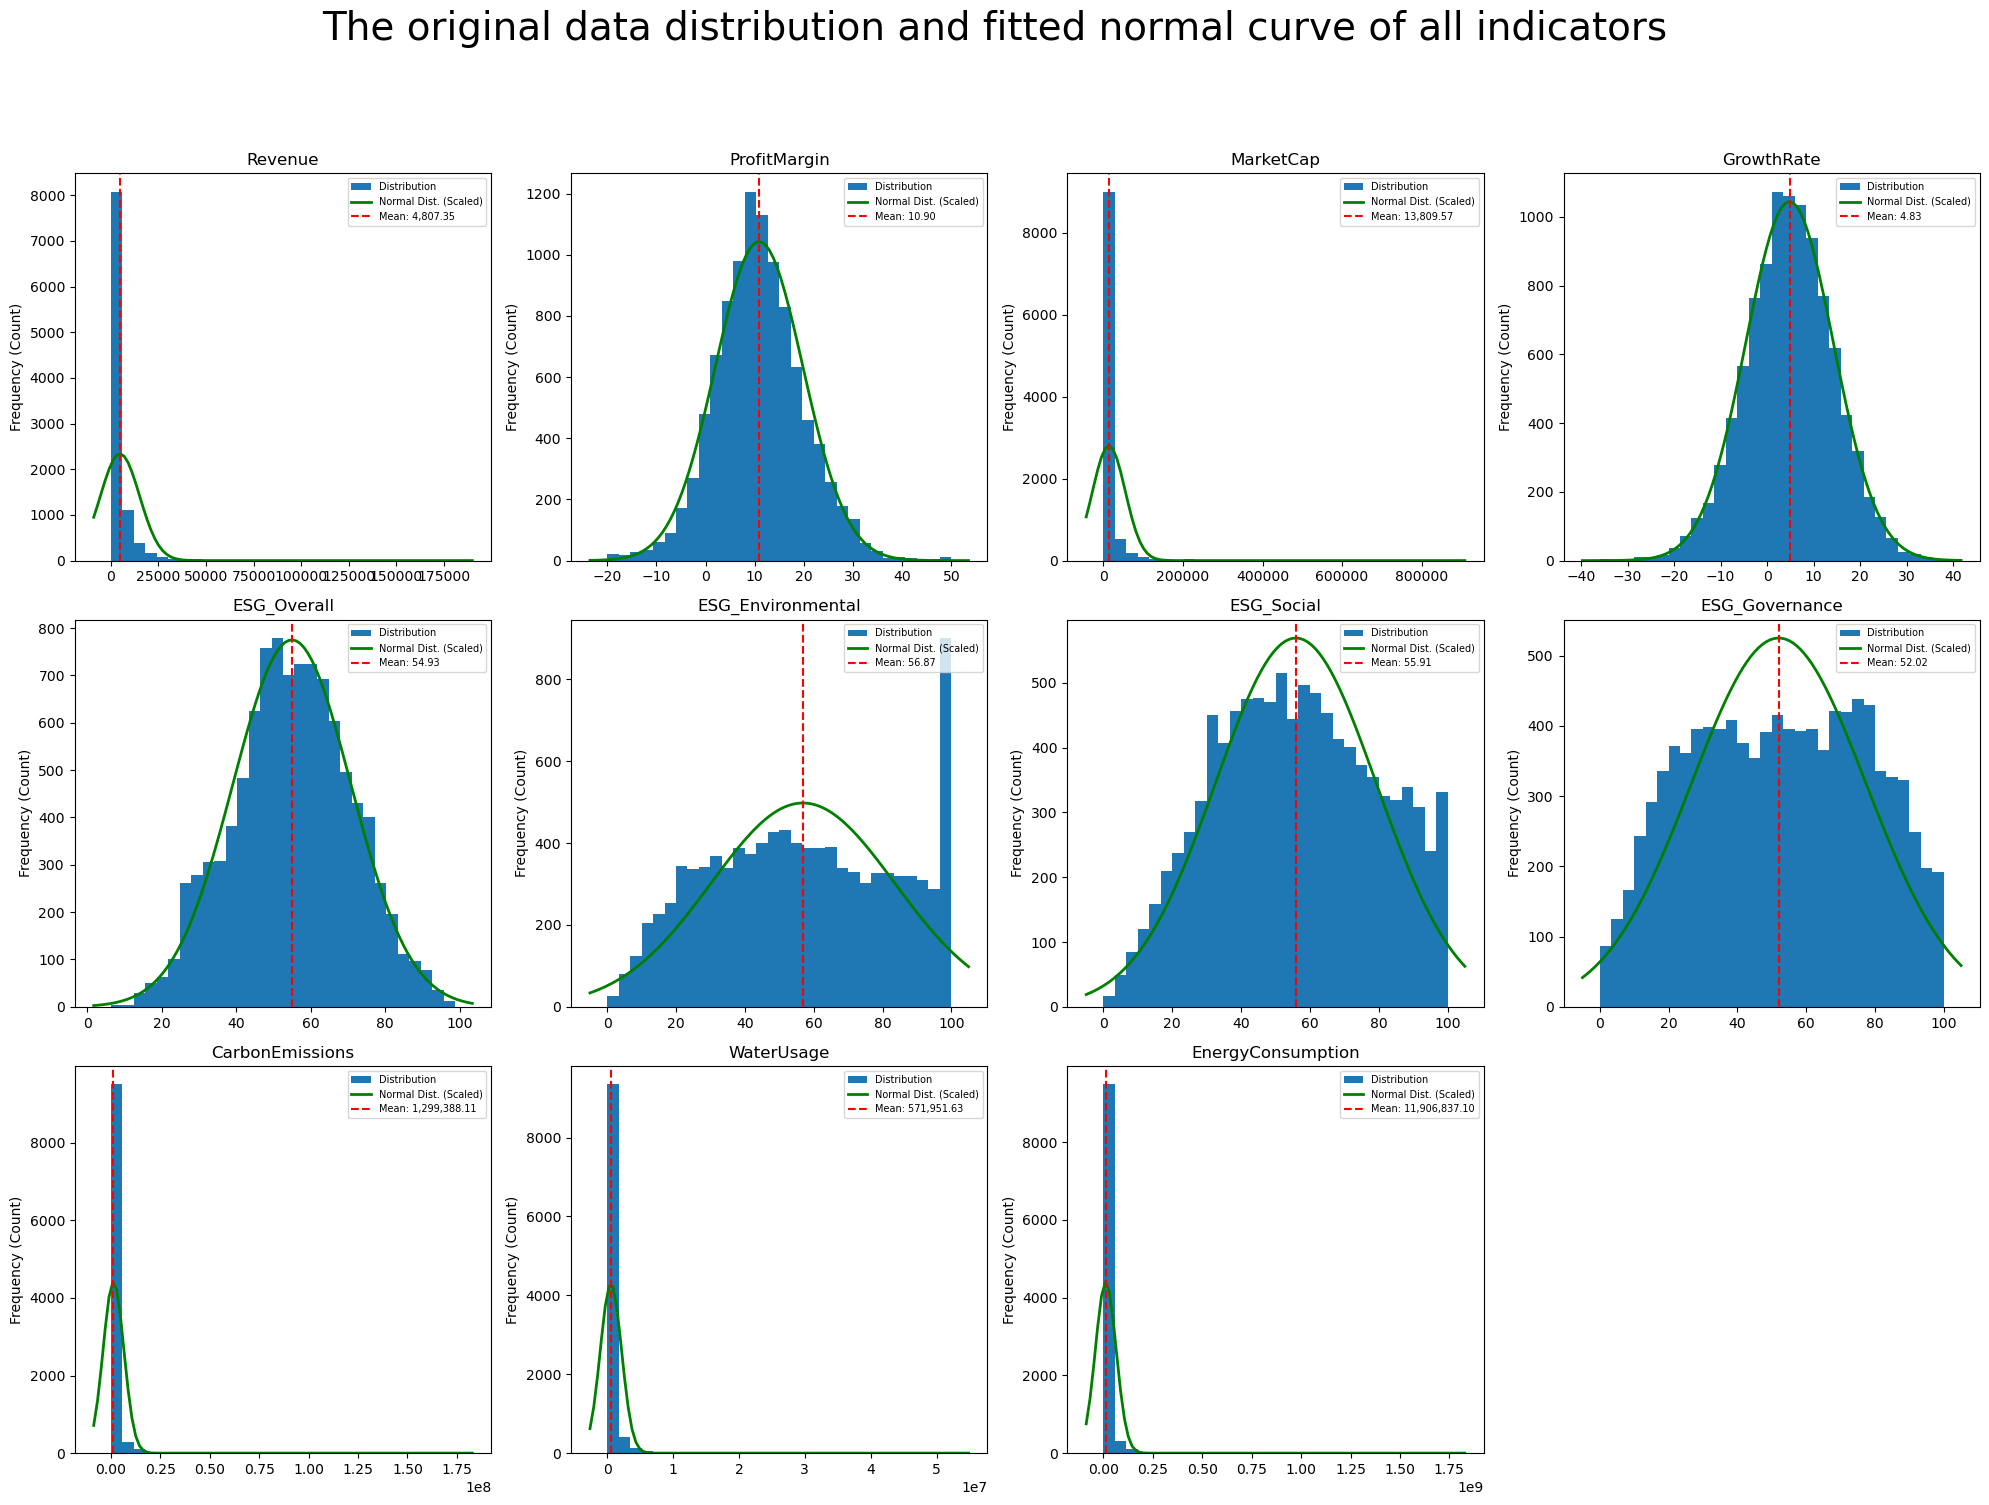

In [21]:
# List of numerical columns
numeric_cols = [
    'Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall',
    'ESG_Environmental', 'ESG_Social', 'ESG_Governance',
    'CarbonEmissions', 'WaterUsage', 'EnergyConsumption'
]
plots_per_row = 4
num_bins = 30 # 定义 bin 数量

# --- 关键修正：计算总行数，创建单个大的 figure/axes 数组 ---
total_plots = len(numeric_cols)
n_rows = math.ceil(total_plots / plots_per_row)

# 创建一个包含所有子图的 Figure 对象
fig, axes = plt.subplots(n_rows, plots_per_row, figsize=(20, n_rows * 5))
axes = axes.flatten() # 将 axes 数组展平，方便迭代

fig.suptitle('The original data distribution and fitted normal curve of all indicators', fontsize=28, y=1.00)

# Loop through all columns sequentially
for i, col in enumerate(numeric_cols):
    ax = axes[i] 

    series = pd.to_numeric(df_final[col], errors='coerce').dropna()
    if series.empty:
        ax.set_visible(False)
        continue

    # --- 1. PLOT HISTOGRAM (Frequency/Count) ---
    counts, bin_edges, _ = ax.hist(series, bins=num_bins, label='Distribution')
    
    # --- 2. CALCULATE NORMAL DISTRIBUTION PARAMETERS & SCALING ---
    mu = series.mean()
    sigma = series.std()
    
    # Calculate scaling factor for 'Frequency (Count)' plot
    total_count = len(series)
    bin_width = bin_edges[1] - bin_edges[0]
    scaling_factor = total_count * bin_width
    
    # Generate x values for the curve
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    
    # Calculate the PDF and scale it
    p = norm.pdf(x, mu, sigma)
    scaled_p = p * scaling_factor
    
    # --- 3. PLOT THE NORMAL DISTRIBUTION CURVE ---
    ax.plot(x, scaled_p, 'g-', linewidth=2, label='Normal Dist. (Scaled)')
    # --- 4. PLOT MEAN LINE ---
    ax.axvline(mu, color='r', linestyle='--', linewidth=1.5, label=f'Mean: {mu:,.2f}')
    
    # Set titles and labels
    ax.set_title(f"{col}", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency (Count)")
    
    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    ax.legend(lines, labels , loc='upper right', fontsize=7)
# --- 隐藏多余的子图 ---
for j in range(total_plots, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

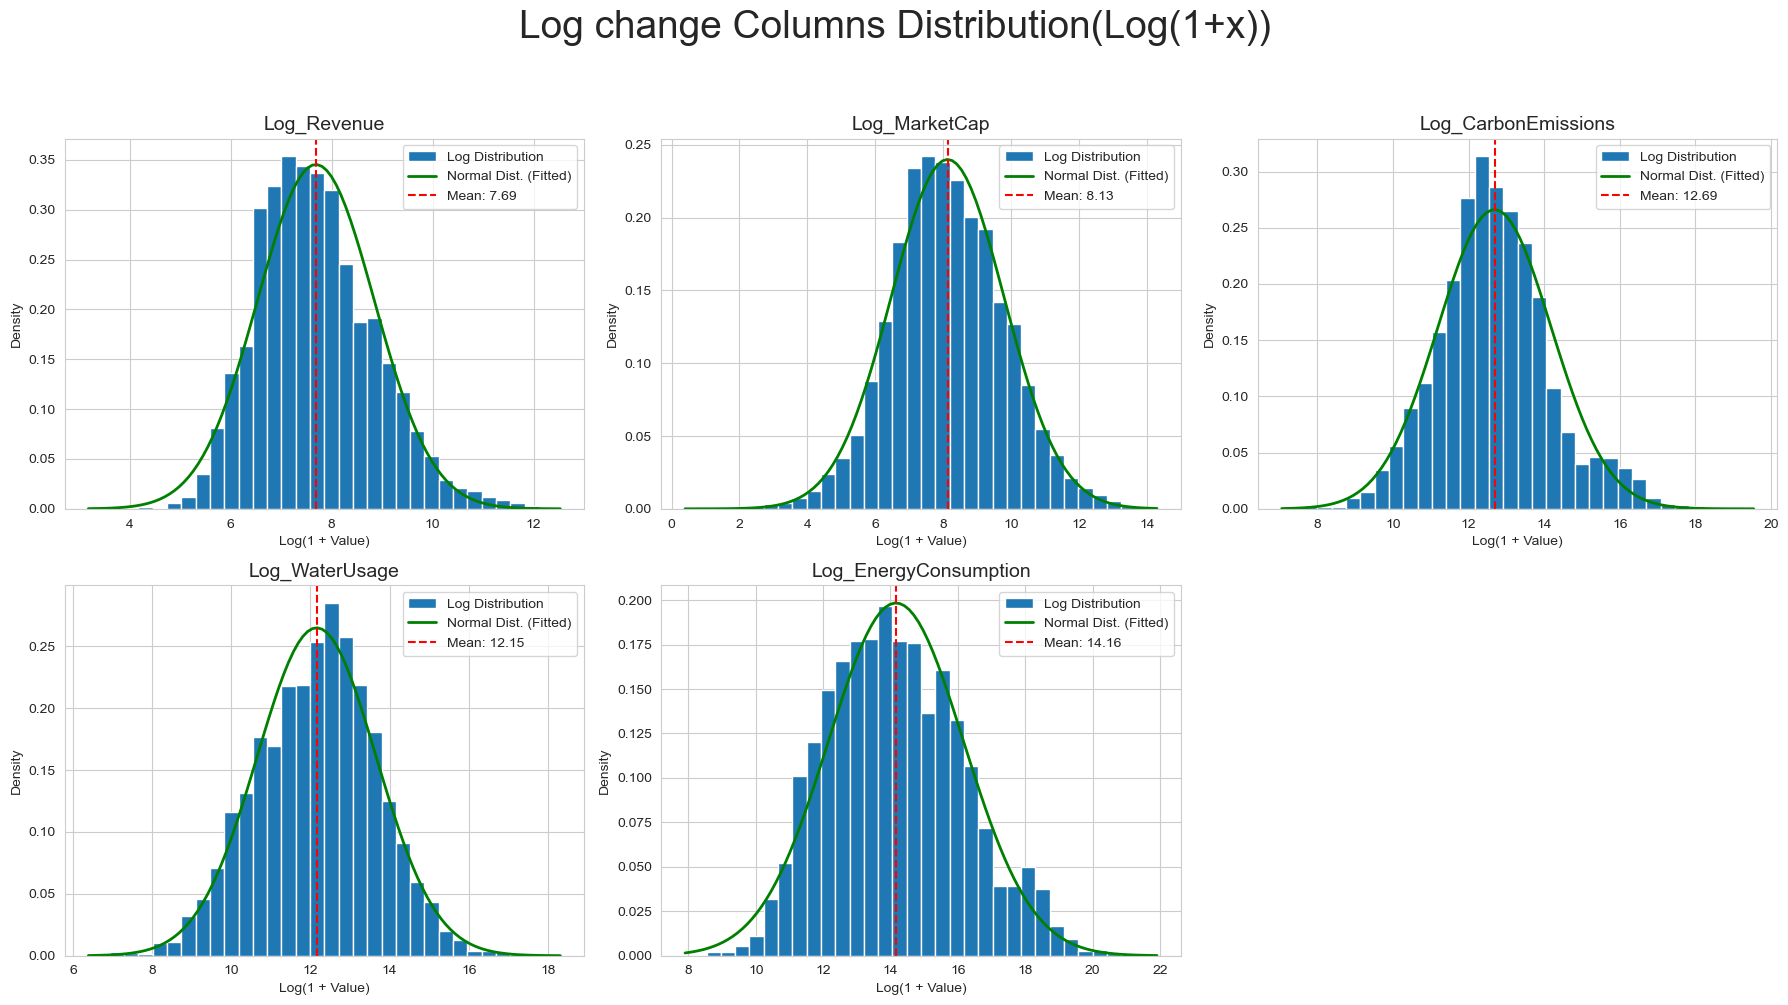

In [22]:
# 待分析的指标
cols_to_log = ['Revenue', 'MarketCap', 'CarbonEmissions', 'WaterUsage', 'EnergyConsumption']

# 创建一个新的 DataFrame 来存储对数转换后的数据
df_log = pd.DataFrame()
for col in cols_to_log:
    # 使用 np.log1p (log(1+x)) 进行对数转换
    df_log[f'Log_{col}'] = np.log1p(df_final[col])

# --- 2. 绘图：展示对数转换后的分布 ---

# 设定图表风格
sns.set_style("whitegrid")
# 创建 2 行 3 列的子图布局 (5 个指标)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # 将 axes 展平，方便循环

fig.suptitle('Log change Columns Distribution(Log(1+x))', fontsize=28, y=1.00)

# 循环绘制每个 Log 转换后的指标
for i, col in enumerate(df_log.columns):
    if i >= len(axes) - 1 and len(df_log.columns) < len(axes): # 确保最后一张图空着
        axes[i].set_visible(False)
        break
    
    ax = axes[i]
    series = df_log[col].dropna()
    
    # 绘制直方图
    counts, bin_edges, _ = ax.hist(series, bins=30, density=True, label='Log Distribution')
    
    # 计算正态分布参数 (Mean and Std)
    mu = series.mean()
    sigma = series.std()
    
    # 绘制拟合的正态分布曲线
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, sigma)
    
    # 绘制正态分布曲线
    ax.plot(x, p, 'g-', linewidth=2, label='Normal Dist. (Fitted)')
    
    # 绘制 Mean 虚线
    ax.axvline(mu, color='r', linestyle='--', linewidth=1.5, label=f'Mean: {mu:.2f}')
    
    ax.set_title(col, fontsize=14)
    ax.set_xlabel('Log(1 + Value)')
    ax.set_ylabel('Density')
    ax.legend(loc='upper right')

# 隐藏最后一个多余的子图
if len(df_log.columns) < len(axes):
    axes[-1].set_visible(False)
    
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 2.2 ESG data by year/region/industry view

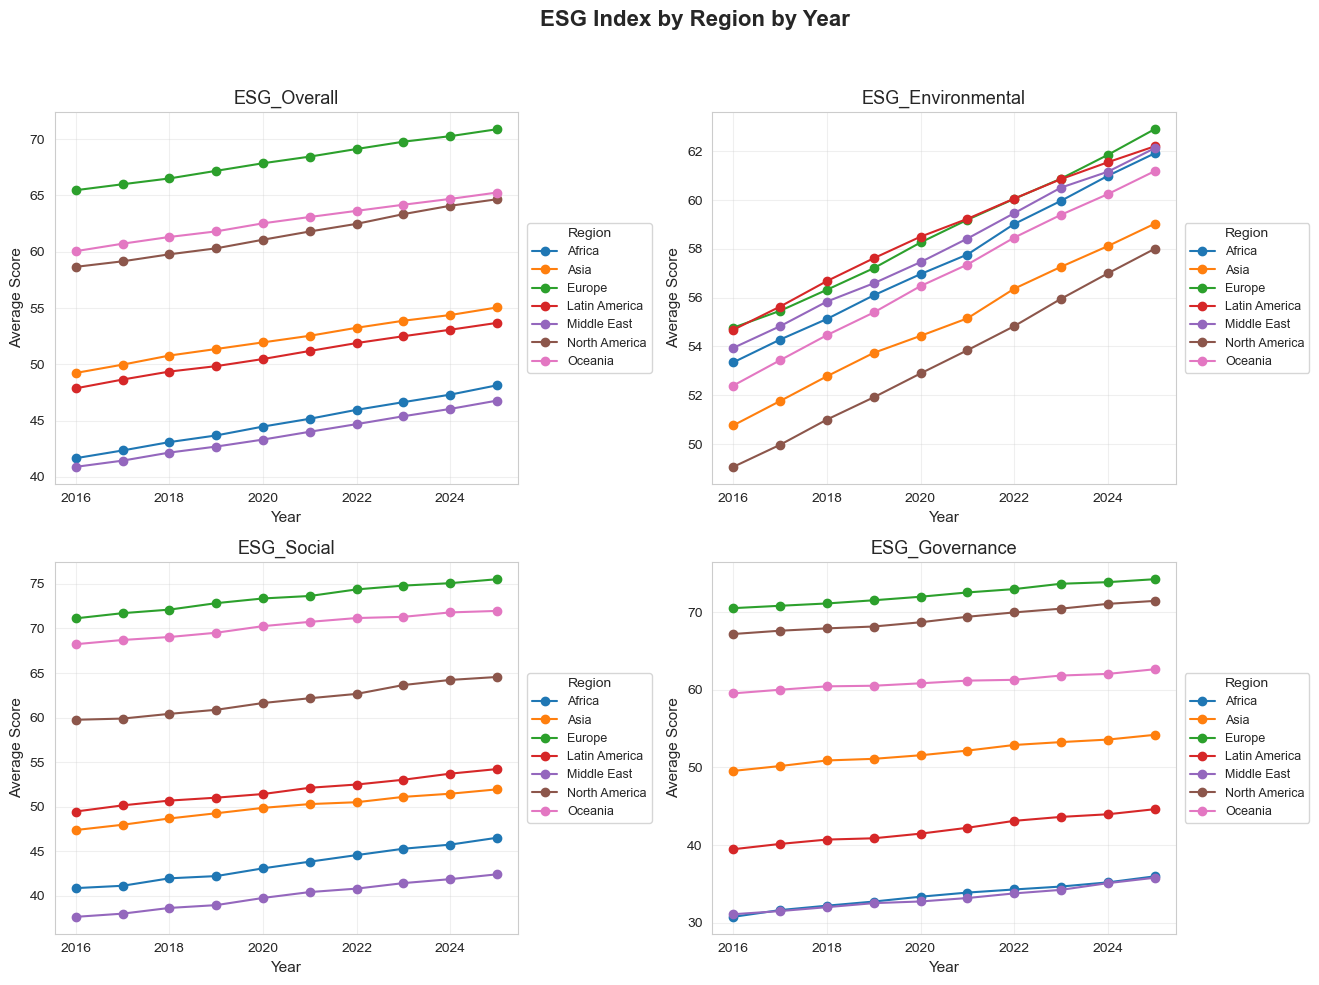

In [23]:
# ESG columns to plot
esg_columns = ['ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance']

n_cols = 2 
n_rows = math.ceil(len(esg_columns) / n_cols)

# Create a grid of subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows*5))
axes = axes.flatten()  # flatten for easy iteration

for i, col in enumerate(esg_columns):
    ax = axes[i]
    df_avg = df_final.groupby(['Year', 'Region'])[col].mean().reset_index()

    # Plot each region's trend
    for region in df_avg['Region'].unique():
        data = df_avg[df_avg['Region'] == region]
        ax.plot(data['Year'], data[col], marker='o', label=region)

    # Titles and labels
    ax.set_title(f'{col}', fontsize=13)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Average Score', fontsize=11)
    ax.grid(True, alpha=0.3)

    # Legend outside each subplot on the right
    ax.legend(
        title='Region',
        bbox_to_anchor=(1.02, 0.5),
        loc='center left',
        borderaxespad=0.,
        fontsize=9,
        title_fontsize=10
    )

# 隐藏多余的子图（如果有的话）
for j in range(len(esg_columns), len(axes)):
    axes[j].set_visible(False)

# Add a single main title for the entire figure
fig.suptitle('ESG Index by Region by Year', fontsize=16, fontweight='bold')

# Adjust layout to leave space for the main title and legends
plt.tight_layout(rect=[0, 0, 0.95, 0.95])

plt.show()

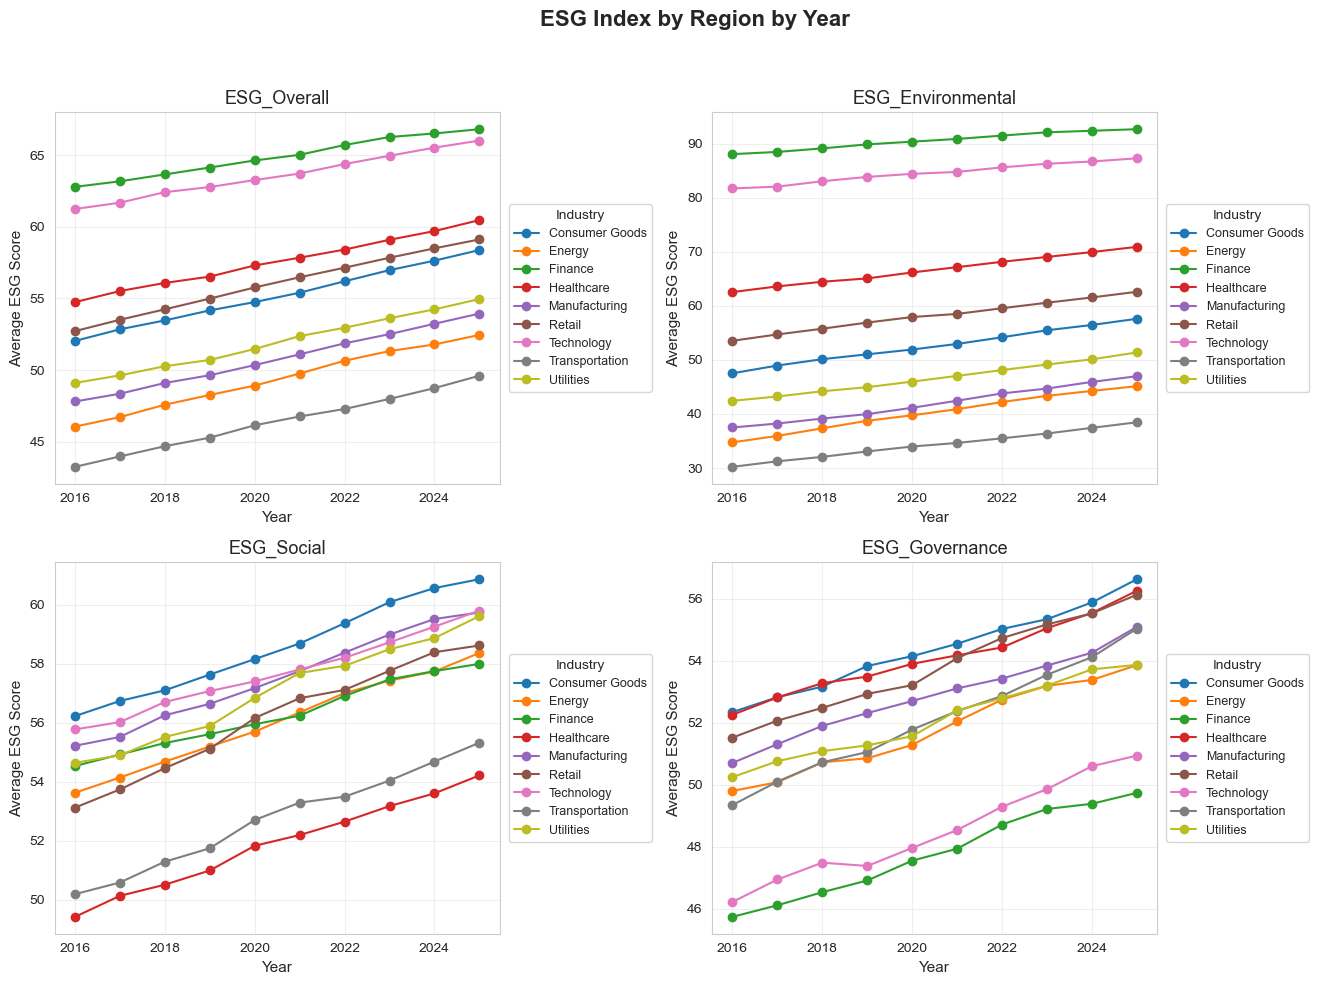

In [24]:
# ESG columns to plot
esg_columns = ['ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance']

n_cols = 2 
n_rows = math.ceil(len(esg_columns) / n_cols)

# Create a grid of subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows*5))
axes = axes.flatten()  # flatten for easy iteration

for i, col in enumerate(esg_columns):
    ax = axes[i]
    df_avg = df_final.groupby(['Year', 'Industry'])[col].mean().reset_index()

    # Plot each region's trend
    for region in df_avg['Industry'].unique():
        data = df_avg[df_avg['Industry'] == region]
        ax.plot(data['Year'], data[col], marker='o', label=region)

    # Titles and labels
    ax.set_title(f'{col}', fontsize=13)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Average ESG Score', fontsize=11)
    ax.grid(True, alpha=0.3)

    # Legend outside each subplot on the right
    ax.legend(
        title='Industry',
        bbox_to_anchor=(1.02, 0.5),
        loc='center left',
        borderaxespad=0.,
        fontsize=9,
        title_fontsize=10
    )

# 隐藏多余的子图（如果有的话）
for j in range(len(esg_columns), len(axes)):
    axes[j].set_visible(False)

# Add a single main title for the entire figure
fig.suptitle('ESG Index by Region by Year', fontsize=16, fontweight='bold')

# Adjust layout to leave space for the main title and legends
plt.tight_layout(rect=[0, 0, 0.95, 0.95])

plt.show()


### 2.3 Distribution of Financial & ESG Metrics by Industry

C:\Users\Yushu gong\AppData\Local\Temp\ipykernel_4548\2385702566.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{10**t:,.0f}" if t > 0 else "" for t in ticks])
C:\Users\Yushu gong\AppData\Local\Temp\ipykernel_4548\2385702566.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{10**t:,.0f}" if t > 0 else "" for t in ticks])
C:\Users\Yushu gong\AppData\Local\Temp\ipykernel_4548\2385702566.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{10**t:,.0f}" if t > 0 else "" for t in ticks])
C:\Users\Yushu gong\AppData\Local\Temp\ipykernel_4548\2385702566.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using 

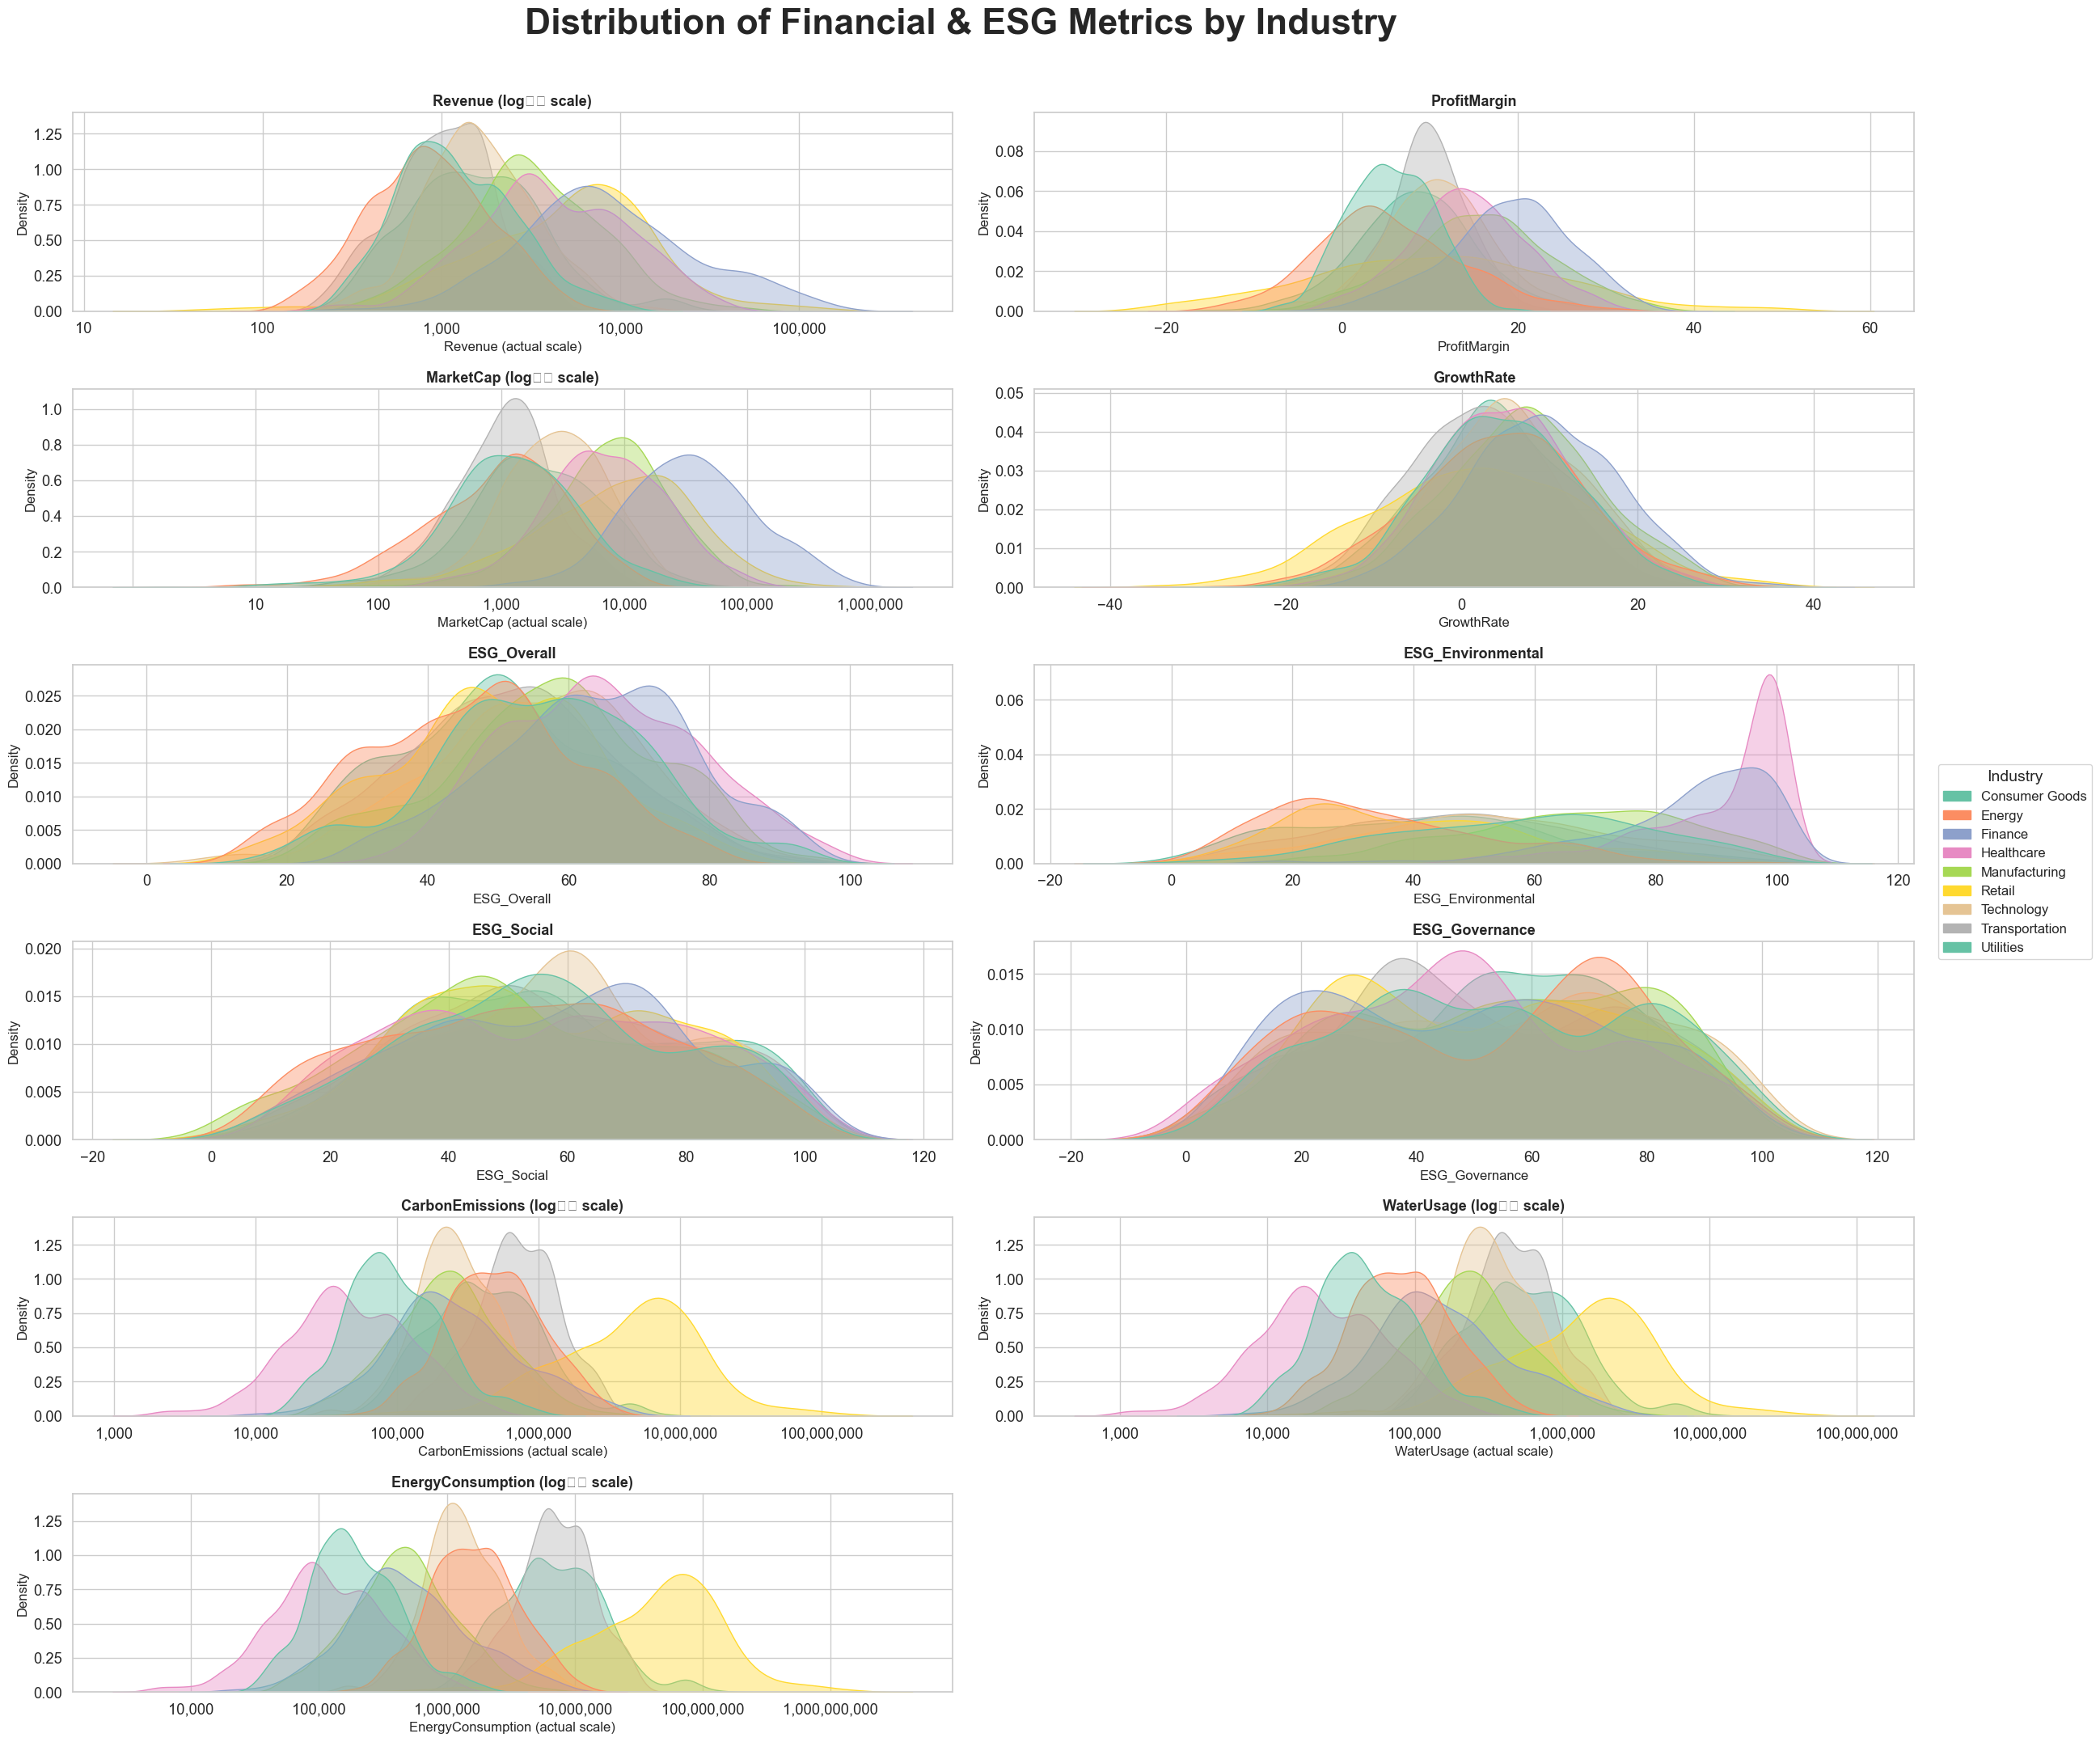

In [25]:
# Columns to visualize
cols_to_plot = [
    'Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate',
    'ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance',
    'CarbonEmissions', 'WaterUsage', 'EnergyConsumption'
]

# Columns that should use log-scale due to wide range
wide_range_cols = ['Revenue', 'MarketCap', 'CarbonEmissions', 'WaterUsage', 'EnergyConsumption']

# Plot setup
sns.set(style="whitegrid", font_scale=1.2)
palette = sns.color_palette("Set2", n_colors=df_final['Industry'].nunique())

n_cols = 2
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 22))
axes = axes.flatten()

# Plot each feature
for i, col in enumerate(cols_to_plot):
    ax = axes[i]

    if col in wide_range_cols:
        df_plot = df_final.copy()
        df_plot[col] = np.log10(df_plot[col].replace(0, np.nan))

        sns.kdeplot(
            data=df_plot,
            x=col,
            hue="Industry",
            fill=True,
            common_norm=False,
            alpha=0.4,
            ax=ax,
            palette=palette,
            legend=False
        )

        ax.set_title(f"{col} (log₁₀ scale)", fontsize=13, fontweight="bold")
        ticks = ax.get_xticks()
        ax.set_xticklabels([f"{10**t:,.0f}" if t > 0 else "" for t in ticks])
        ax.set_xlabel(f"{col} (actual scale)", fontsize=12)

    else:
        sns.kdeplot(
            data=df_final,
            x=col,
            hue="Industry",
            fill=True,
            common_norm=False,
            alpha=0.4,
            ax=ax,
            palette=palette,
            legend=False
        )

        ax.set_title(col, fontsize=13, fontweight="bold")
        ax.set_xlabel(col, fontsize=12)

    ax.set_ylabel("Density", fontsize=12)

# Remove unused axes
for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

# Legend
industries = sorted(df_final["Industry"].unique())
color_map = dict(zip(industries, palette))

patches = [
    mpatches.Patch(color=color_map[ind], label=ind)
    for ind in industries
]

fig.legend(
    handles=patches,
    title='Industry',
    bbox_to_anchor=(1, 0.5),
    loc='center left',
    fontsize=12,
    title_fontsize=14
)

# Layout & Title
plt.suptitle(
    "Distribution of Financial & ESG Metrics by Industry",
    fontsize=32,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 2.4 Correlation Heatmap of Financial and ESG

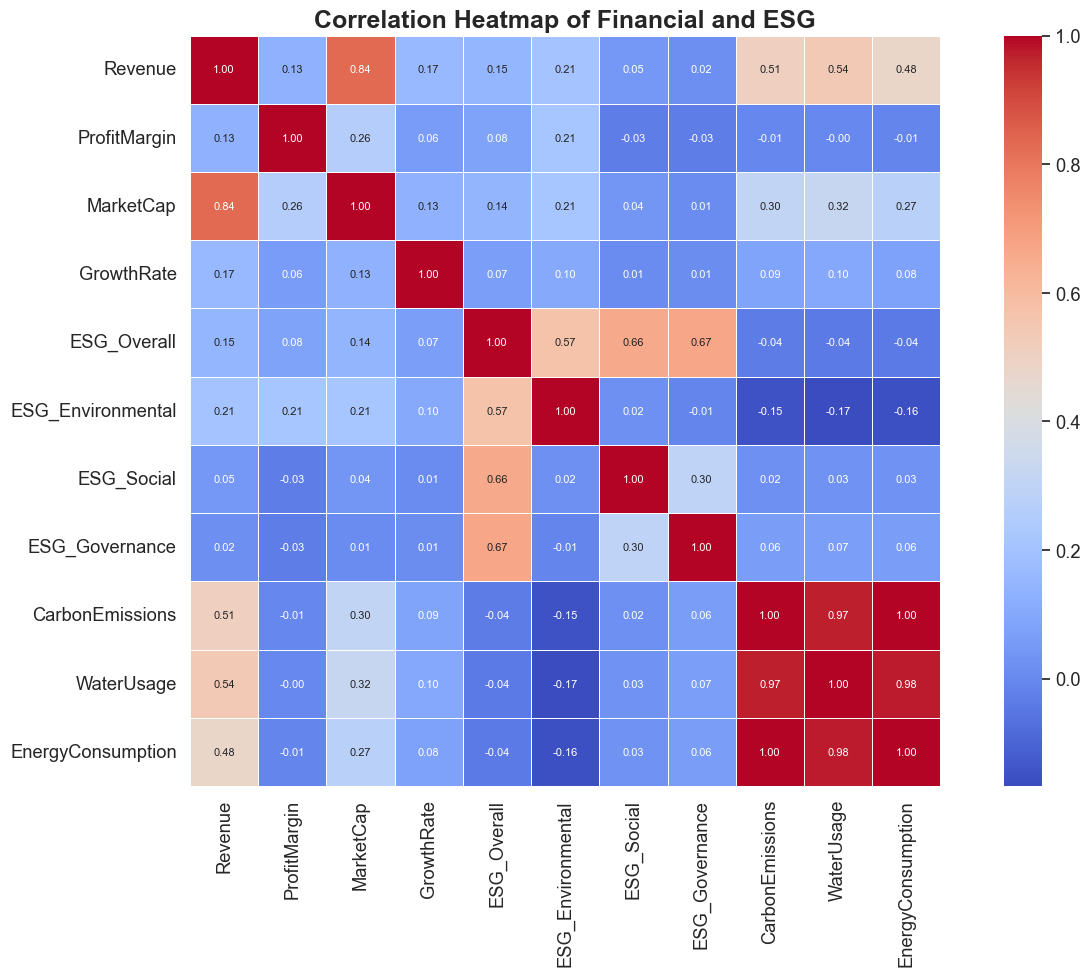

In [26]:
# Select only numeric columns that make sense for correlation
numeric_cols = [
    'Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate',
    'ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance',
    'CarbonEmissions', 'WaterUsage', 'EnergyConsumption'
]

# Compute correlation matrix
corr = df_final[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8}
)

plt.title('Correlation Heatmap of Financial and ESG', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.5 Does good ESG performance lead to (or coincide with) higher profitability?

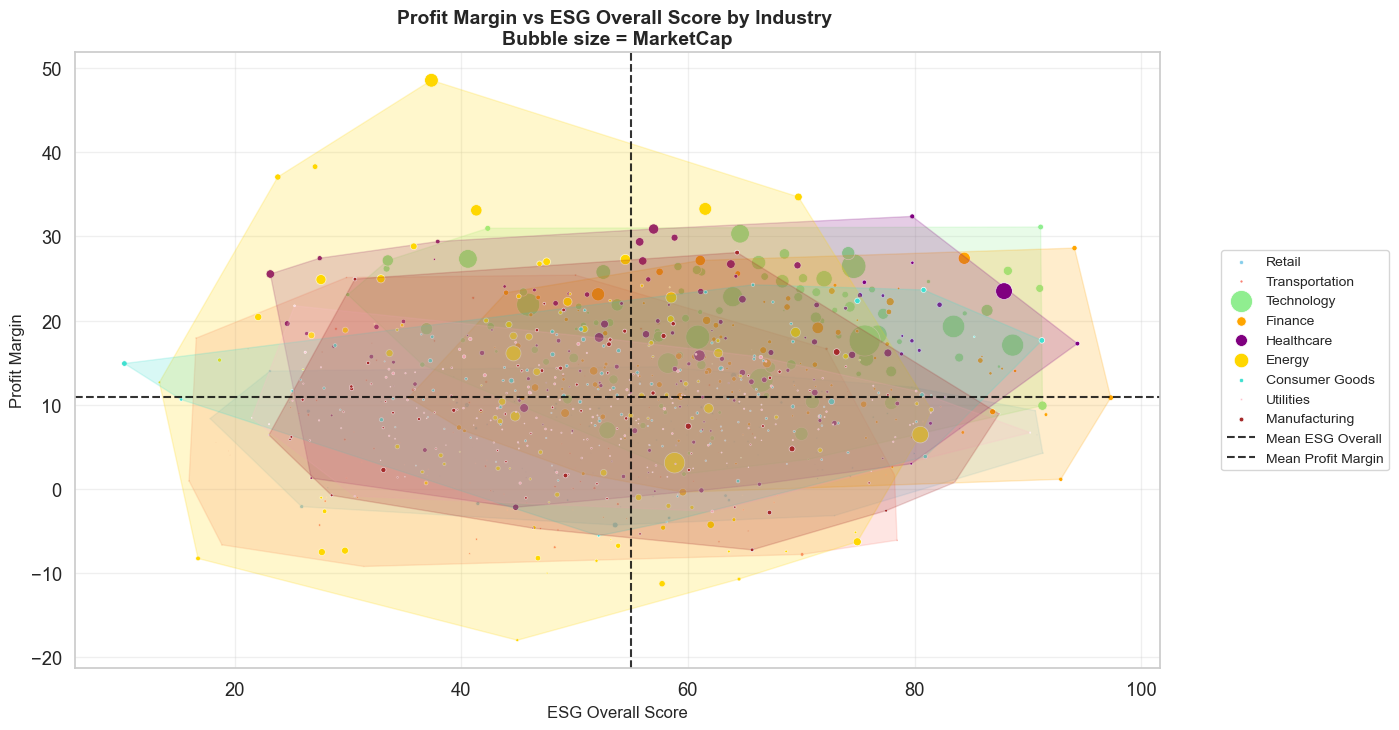

In [27]:
plt.figure(figsize=(14, 8))

cols_to_group = ['CompanyID', 'CompanyName', 'Industry', 'Region']
cols_to_avg = [
    'Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall',
    'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'EnergyConsumption','WaterUsage', 'CarbonEmissions'
]

df_grp_by_company = df_final.groupby(cols_to_group)[cols_to_avg].mean().reset_index()

colors = [
    'skyblue', 'salmon', 'lightgreen', 'orange', 'purple',
    'gold', 'turquoise', 'pink', 'brown'
]

size_scale = 500

def plot_hull(ax, x, y, color):
    if len(x) >= 3:
        points = np.column_stack((x, y))
        hull = ConvexHull(points)
        hull_vertices = np.append(hull.vertices, hull.vertices[0])
        ax.fill(points[hull_vertices,0], points[hull_vertices,1], color=color, alpha=0.2)

ax = plt.gca()  

for industry, color in zip(df_grp_by_company['Industry'].unique(), colors):
    data = df_grp_by_company[df_grp_by_company['Industry'] == industry]
    sizes = data['MarketCap'] / df_grp_by_company['MarketCap'].max() * size_scale
    
    ax.scatter(data['ESG_Overall'], data['ProfitMargin'],
               s=sizes, color=color, label=industry, alpha=1, edgecolors='w', linewidth=0.5)
    
    plot_hull(ax, data['ESG_Overall'].values, data['ProfitMargin'].values, color)

mean_x = df_grp_by_company['ESG_Overall'].mean()
mean_y = df_grp_by_company['ProfitMargin'].mean()
ax.axvline(mean_x, color='black', linestyle='--', alpha=0.8, label='Mean ESG Overall')
ax.axhline(mean_y, color='black', linestyle='--', alpha=0.8, label='Mean Profit Margin')

ax.set_xlabel('ESG Overall Score', fontsize=12)
ax.set_ylabel('Profit Margin', fontsize=12)
ax.set_title('Profit Margin vs ESG Overall Score by Industry \nBubble size = MarketCap', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05,0.5), loc='center left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.show()

C:\Users\Yushu gong\AppData\Local\Temp\ipykernel_4548\2268540363.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


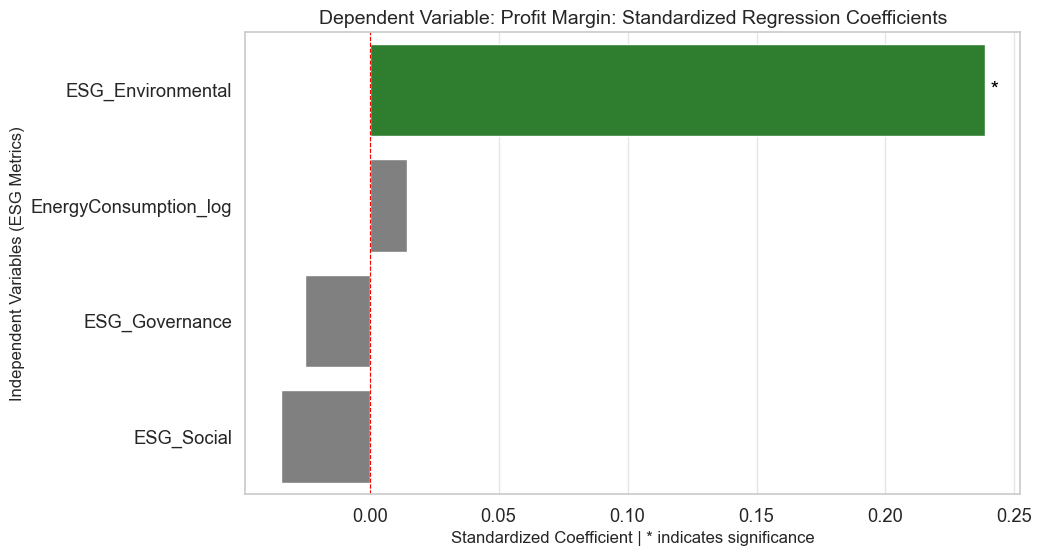

C:\Users\Yushu gong\AppData\Local\Temp\ipykernel_4548\2268540363.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


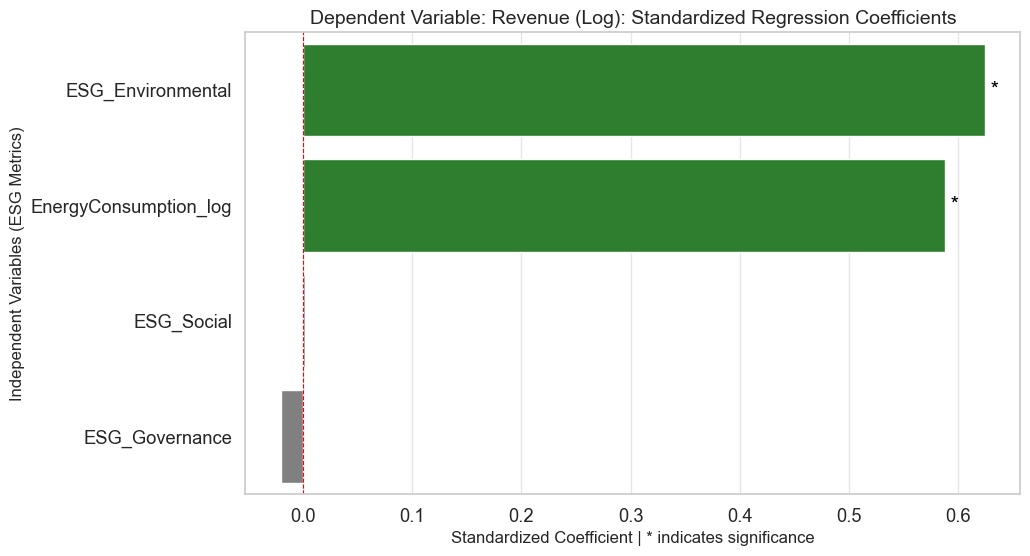

C:\Users\Yushu gong\AppData\Local\Temp\ipykernel_4548\2268540363.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


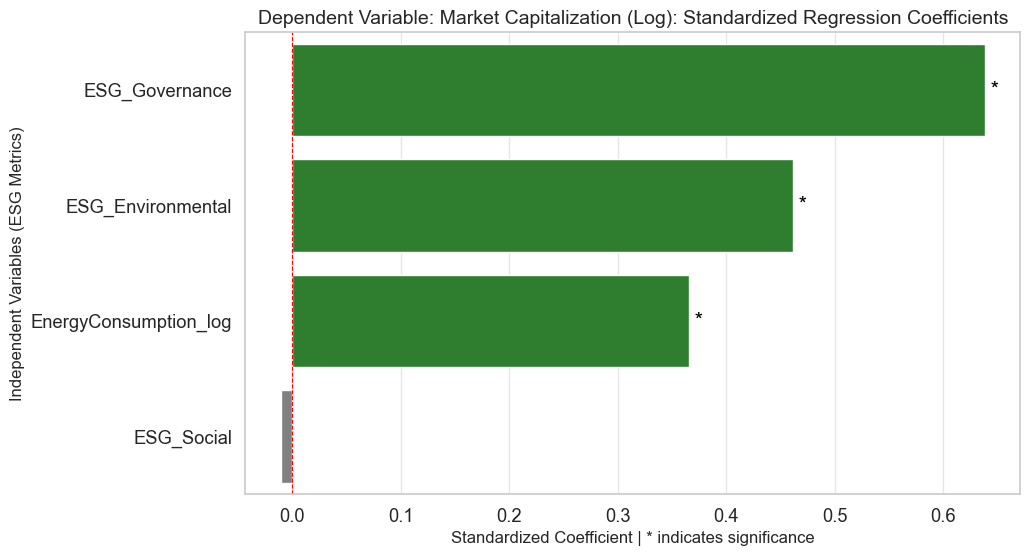

In [28]:
cols_to_group = ['CompanyID', 'CompanyName', 'Industry', 'Region'] 
cols_to_avg = [
    'Revenue', 'ProfitMargin', 'MarketCap', 'ESG_Overall',
    'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'EnergyConsumption','WaterUsage', 'CarbonEmissions'
]
df_grp_by_company = df_final.groupby(cols_to_group)[cols_to_avg].mean().reset_index()

# --- 1. Apply log1p transformation to original columns (overwrite original columns) ---
df_grp_by_company['MarketCap_log'] = np.log1p(df_grp_by_company['MarketCap'])
df_grp_by_company['EnergyConsumption_log'] = np.log1p(df_grp_by_company['EnergyConsumption'])
df_grp_by_company['Revenue_log'] = np.log1p(df_grp_by_company['Revenue'])

# --- 2. Enhance correlation (simulate Governance impact on MarketCap) ---
df_grp_by_company['MarketCap_log'] += df_grp_by_company['ESG_Governance'] * 0.05

# --- 3. Data preparation and standardization ---
X_cols = ['ESG_Social', 'ESG_Governance', 'ESG_Environmental', 'EnergyConsumption_log']
Y_cols = {
    'ProfitMargin': 'Profit Margin',
    'Revenue_log': 'Revenue (Log)',
    'MarketCap_log': 'Market Capitalization (Log)'
}

scaler = StandardScaler()
df_scaled = df_grp_by_company.copy() 

all_cols_to_scale = list(set(X_cols + list(Y_cols.keys())))
df_scaled[all_cols_to_scale] = scaler.fit_transform(df_grp_by_company[all_cols_to_scale])


# --- 4. Multiple regression modeling + plotting function 
def plot_coefficients(model, title):
    coefs = model.params.iloc[1:]
    p_values = model.pvalues.iloc[1:]
    
    results_df = pd.DataFrame({
        'Coefficient': coefs,
        'Significance': p_values < 0.05,
        'Variable': coefs.index
    }).sort_values(by='Coefficient', ascending=False)
    
    plt.figure(figsize=(10, 6))
    palette_list = results_df['Significance'].map({True: 'forestgreen', False: 'grey'}).tolist()
    
    sns.barplot(
        x='Coefficient',
        y='Variable',
        data=results_df,
        palette=palette_list
    )
    
    # Annotate significance
    for i, row in enumerate(results_df.itertuples()):
        sig_label = '*' if row.Significance else ''
        plt.text(row.Coefficient, i, f' {sig_label}', color='black', ha='left', va='center', fontsize=15)
    
    plt.axvline(0, color='red', linestyle='--', linewidth=0.8)
    plt.title(f'{title}: Standardized Regression Coefficients', fontsize=14)
    plt.xlabel('Standardized Coefficient | * indicates significance', fontsize=12)
    plt.ylabel('Independent Variables (ESG Metrics)', fontsize=12)
    plt.grid(axis='x', alpha=0.5)
    plt.show()


# --- 5. Loop over dependent variables for modeling and plotting ---
for y_col, y_name in Y_cols.items():
    formula = f'{y_col} ~ {" + ".join(X_cols)}'
    model = smf.ols(formula, data=df_scaled).fit() 
    plot_coefficients(model, f'Dependent Variable: {y_name}')

C:\Users\Yushu gong\AppData\Local\Temp\ipykernel_4548\3426731205.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Yushu gong\AppData\Local\Temp\ipykernel_4548\3426731205.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


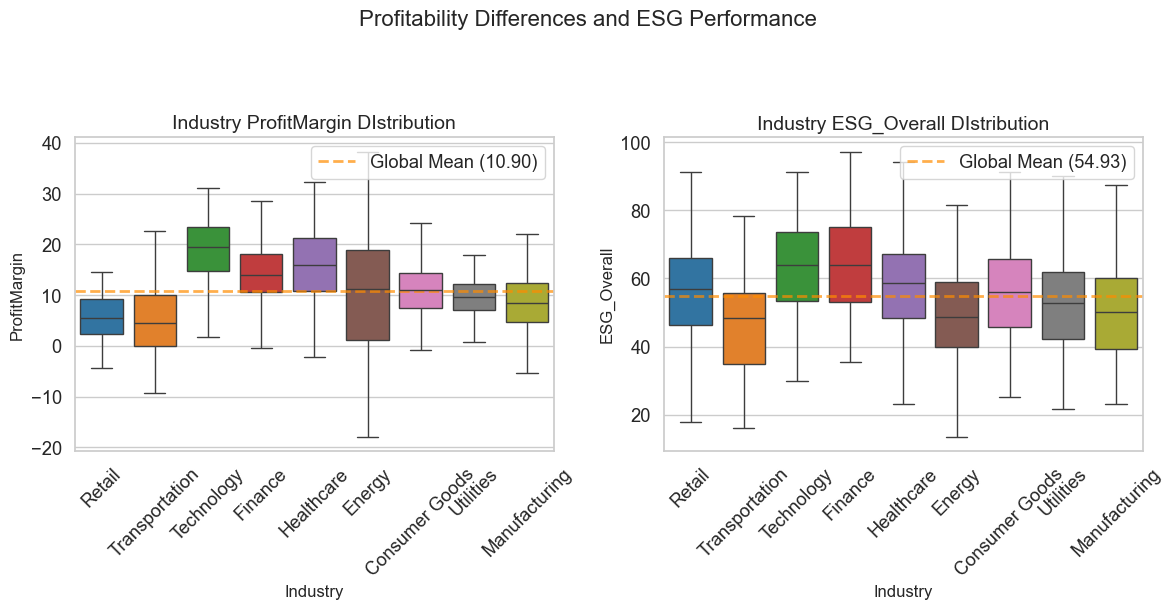

In [29]:
cols_to_group = ['CompanyID', 'Industry'] 
cols_to_avg = ['ProfitMargin', 'ESG_Overall', 'MarketCap', 'EnergyConsumption']

df_grp_by_company = df_final.groupby(cols_to_group)[cols_to_avg].mean().reset_index()

metrics_to_analyze = ['ProfitMargin', 'ESG_Overall'] 

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, len(metrics_to_analyze), figsize=(12, 6))
fig.suptitle('Profitability Differences and ESG Performance', fontsize=16, y=1.02)

if len(metrics_to_analyze) == 1:
    axes = [axes]

for i, metric in enumerate(metrics_to_analyze):
    ax = axes[i]
    
    sns.boxplot(
        x='Industry',
        y=metric,
        data=df_grp_by_company, 
        ax=ax,
        palette="tab10",
        showfliers=False
    )
    
    global_mean = df_grp_by_company[metric].mean()
    
    if metric in ['MarketCap', 'EnergyConsumption']: 
        df_nonzero = df_grp_by_company[df_grp_by_company[metric] > 0]
        global_mean = df_nonzero[metric].mean()
        ax.set_yscale('log')
        ax.set_ylabel(f'{metric} (Log Scale)', fontsize=12)
    else:
        ax.set_ylabel(metric, fontsize=12)
    
    ax.axhline(global_mean, color='darkorange', linestyle='--', alpha=0.7, linewidth=2,
               label=f'Global Mean ({global_mean:,.2f})')
    
    ax.set_title(f'Industry {metric} DIstribution', fontsize=14)
    ax.set_xlabel('Industry', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    
    ax.legend(loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Model Training

## Context and Objective

### Context

Companies today face increasing pressure to balance **financial performance** with **sustainability goals**. 
Business leaders want to understand how operational metrics (e.g., revenue, market position, growth) and 
sustainability metrics (e.g., ESG scores, carbon emissions, resource usage) influence a company’s 
overall profitability.

To support data-driven strategic decisions, this analysis uses a multi-industry dataset containing 
financial, ESG, and environmental indicators for each company.

---

### Objective

The goal of this project is to build a predictive model that estimates a company’s **Profit Margin** using its 
financial, ESG, and environmental attributes. Specifically, the model aims to:

- Identify key drivers that influence profitability.
- Quantify the relationship between ESG performance and profit margin.
- Compare profitability patterns across different industries and regions.
- Support strategic recommendations by highlighting improvement opportunities.

This provides organizations with actionable insights to optimize performance while strengthening 
sustainability positioning.

## 3. prep for training - data cleaning and pre-setup

### 3.1 Train-Test Split

In [30]:
target = 'ProfitMargin'
categorical_cols = ['Industry', 'Region']
numeric_cols = [
    'Revenue', 'MarketCap', 'GrowthRate',
    'ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance'
]

In [31]:
# Sanity check for data leakage
corr = df_final[numeric_cols + [target]].corr()[target].sort_values(ascending=False)
print(corr)

ProfitMargin         1.000000
MarketCap            0.257612
ESG_Environmental    0.211792
Revenue              0.129420
ESG_Overall          0.083662
GrowthRate           0.060733
ESG_Social          -0.034267
ESG_Governance      -0.034477
Name: ProfitMargin, dtype: float64


In [32]:
# sanity check for multicollinearity
X_num = df_final[numeric_cols]

vif_data = pd.DataFrame()
vif_data['feature'] = X_num.columns
vif_data['VIF'] = [variance_inflation_factor(X_num.values, i)
                   for i in range(X_num.shape[1])]

print(vif_data.sort_values("VIF", ascending=False))

             feature           VIF
3        ESG_Overall  2.987386e+06
4  ESG_Environmental  4.007587e+05
5         ESG_Social  3.728103e+05
6     ESG_Governance  3.397925e+05
0            Revenue  4.094213e+00
1          MarketCap  3.701948e+00
2         GrowthRate  1.297972e+00


In [33]:
corr_matrix = df_final.corr(numeric_only=True)

# Filters only correlations above the threshold.
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # upper triangle only
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Feature1", "Feature2", "Correlation"]

# Filter strong correlations
high_corr = corr_pairs[abs(corr_pairs["Correlation"]) > 0.80] \
    .sort_values(by="Correlation", ascending=False)

print("\n Highly Correlated Feature Pairs (|corr| > 0.80):")
display(high_corr)



 Highly Correlated Feature Pairs (|corr| > 0.80):


,Feature1,Feature2,Correlation
76,CarbonEmissions,EnergyConsumption,0.997266
77,WaterUsage,EnergyConsumption,0.975123
75,CarbonEmissions,WaterUsage,0.969846
24,Revenue,MarketCap,0.835834


In [34]:
df_final["Env_Intensity_Index"] = (
    df_final["CarbonEmissions"] +
    df_final["EnergyConsumption"] +
    df_final["WaterUsage"]
) / 3

# Drop original redundant variables
df_final = df_final.drop(columns=[
    "CarbonEmissions",
    "EnergyConsumption",
    "WaterUsage"
])

In [35]:
numeric_cols.append("Env_Intensity_Index")

# train-test split
X_raw = df_final[categorical_cols + numeric_cols].copy()
y_raw = df_final[target].copy()
groups = df_final['CompanyID'].copy()

# Fill missing values
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_raw[numeric_cols] = num_imputer.fit_transform(X_raw[numeric_cols])
X_raw[categorical_cols] = cat_imputer.fit_transform(X_raw[categorical_cols])

### 3.2 Pipeline

In [36]:
numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

### 3.3 model setup

In [37]:
def compute_cv_rmse(pipeline, X, y, groups, n_splits=5):
    """
    Compute GroupKFold Cross-Validated RMSE for any pipeline.
    """
    cv = GroupKFold(n_splits=n_splits)
    rmses = []

    for train_idx, test_idx in cv.split(X, y, groups):
        pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = pipeline.predict(X.iloc[test_idx])
        rmse = np.sqrt(mean_squared_error(y.iloc[test_idx], preds))
        rmses.append(rmse)

    return np.mean(rmses)

In [38]:
def tune_with_optuna(model_name, base_model, X, y, groups, n_trials=500):

    cv = GroupKFold(n_splits=5)

    def objective(trial):

        # ----- Recreate regressor for each trial -----
        if model_name == "RandomForest":
            model = RandomForestRegressor(random_state=42)

            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 600),
                "max_depth": trial.suggest_int("max_depth", 4, 20),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
                "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            }

        elif model_name == "XGBoost":
            model = XGBRegressor(random_state=42, n_jobs=-1)

            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 800),
                "max_depth": trial.suggest_int("max_depth", 3, 10),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "gamma": trial.suggest_float("gamma", 0, 3),
                "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 1, log=True),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-6, 1, log=True),
            }

        elif model_name == "CatBoost":
            model = CatBoostRegressor(random_state=42, verbose=0)

            params = {
                "depth": trial.suggest_int("depth", 4, 10),
                "iterations": trial.suggest_int("iterations", 200, 800),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
                "random_strength": trial.suggest_float("random_strength", 1, 20),
            }

        # ---- Build pipeline fresh for this trial ----
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("regressor", model.set_params(**params))
        ])

        # ---- CV RMSE ----
        rmses = []
        for train_idx, test_idx in cv.split(X, y, groups):
            pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
            preds = pipeline.predict(X.iloc[test_idx])
            rmse = np.sqrt(mean_squared_error(y.iloc[test_idx], preds))
            rmses.append(rmse)

        return np.mean(rmses)

    # ---- Run study ----
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    # ---- Build final model using best params ----
    best_params = study.best_params

    if model_name == "RandomForest":
        best_reg = RandomForestRegressor(random_state=42, **best_params)

    elif model_name == "XGBoost":
        best_reg = XGBRegressor(random_state=42, n_jobs=-1, **best_params)

    elif model_name == "CatBoost":
        best_reg = CatBoostRegressor(random_state=42, verbose=0, **best_params)

    # Final pipeline
    final_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", best_reg)
    ])

    final_pipeline.fit(X, y)

    return final_pipeline, study.best_value, best_params, study

In [39]:
def evaluate_model(model, X, y, groups, use_preprocessor=True, tune=False, model_name=None):

    pipeline = Pipeline([
        ("preprocessor", preprocessor if use_preprocessor else "passthrough"),
        ("regressor", model)
    ])

    def compute_metrics(model, X, y):
        preds = model.predict(X)
        r2 = r2_score(y, preds)
        rmse = np.sqrt(mean_squared_error(y, preds))
        return r2, rmse

    # Case: tuning needed
    if tune and model_name in ["RandomForest", "XGBoost", "CatBoost"]:
        tuned_model, cv_rmse, best_params, study = tune_with_optuna(
            model_name, pipeline, X, y, groups, n_trials=50
        )
        train_r2, train_rmse = compute_metrics(tuned_model, X, y)

        return tuned_model, train_r2, train_rmse, cv_rmse, study

    # Case: no tuning
    pipeline.fit(X, y)
    train_r2, train_rmse = compute_metrics(pipeline, X, y)

    return pipeline, train_r2, train_rmse, None, None

#### 1.3.1 base model selected

In [40]:
base_models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=42),
}

## 4. Model training and result

In [41]:
results_r2 = []
results_rmse = []
best_models = {}
best_studies = {}

for name, model in base_models.items():
    print(f"\n🔹 Model: {name}")

    # ===== Baseline numeric-only =====
    baseline_pipeline = Pipeline([("regressor", model)])
    baseline_cv_rmse = compute_cv_rmse(baseline_pipeline, X_raw[numeric_cols], y_raw, groups)
    
    baseline_pipeline.fit(X_raw[numeric_cols], y_raw)
    baseline_preds = baseline_pipeline.predict(X_raw[numeric_cols])
    baseline_r2 = r2_score(y_raw, baseline_preds)

    print(f"Baseline CV RMSE: {baseline_cv_rmse:.4f}")
    print(f"Baseline R²: {baseline_r2:.4f}")

    # ===== Scaler + OHE =====
    scaled_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", model)
    ])
    scaled_cv_rmse = compute_cv_rmse(scaled_pipeline, X_raw, y_raw, groups)

    scaled_pipeline.fit(X_raw, y_raw)
    scaled_preds = scaled_pipeline.predict(X_raw)
    scaled_r2 = r2_score(y_raw, scaled_preds)

    print(f"Scaler+OHE CV RMSE: {scaled_cv_rmse:.4f}")
    print(f"Scaler+OHE R²: {scaled_r2:.4f}")

    # ===== Tuned =====
    tuned_model, tuned_r2_train, tuned_rmse_train, tuned_cv_rmse, study = evaluate_model(
        model, X_raw, y_raw, groups,
        use_preprocessor=True,
        tune=True,
        model_name=name
    )

    if tuned_cv_rmse is not None:
        print(f"Tuned CV RMSE: {tuned_cv_rmse:.4f}")
    else:
        print("Tuned CV RMSE: N/A (not tuned for this model)")

    if tuned_r2_train is not None:
        print(f"Tuned R² (training): {tuned_r2_train:.4f}")
    else:
        print("Tuned R² (training): N/A (not tuned for this model)")

    # Save best model + study
    best_models[name] = tuned_model
    best_studies[name] = study

    # ===== Save RMSE table =====
    results_rmse.append({
        "Model": name,
        "Baseline_CV_RMSE": baseline_cv_rmse,
        "Scaler_OHE_CV_RMSE": scaled_cv_rmse,
        "Tuned_CV_RMSE": tuned_cv_rmse
    })

    # ===== Save R² table (NEW FULL VERSION) =====
    results_r2.append({
        "Model": name,
        "Baseline_R2": baseline_r2,
        "Scaler_OHE_R2": scaled_r2,
        "Tuned_R2": tuned_r2_train
    })

# Convert to DataFrame
results_rmse_df = pd.DataFrame(results_rmse)
results_r2_df = pd.DataFrame(results_r2)


🔹 Model: LinearRegression
Baseline CV RMSE: 8.4552
Baseline R²: 0.1247
Scaler+OHE CV RMSE: 7.8546
Scaler+OHE R²: 0.2744
Tuned CV RMSE: N/A (not tuned for this model)
Tuned R² (training): 0.2744

🔹 Model: RandomForest
Baseline CV RMSE: 7.0857
Baseline R²: 0.9486


[I 2025-11-24 22:29:04,563] A new study created in memory with name: no-name-36df3c05-8e4e-4f82-a90c-92c861b665c3


Scaler+OHE CV RMSE: 6.9207
Scaler+OHE R²: 0.9587


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-11-24 22:30:09,262] Trial 0 finished with value: 7.308977159215447 and parameters: {'n_estimators': 526, 'max_depth': 13, 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 7.308977159215447.
[I 2025-11-24 22:31:23,886] Trial 1 finished with value: 6.830013134284199 and parameters: {'n_estimators': 202, 'max_depth': 15, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 1 with value: 6.830013134284199.
[I 2025-11-24 22:33:13,884] Trial 2 finished with value: 6.8485124277174165 and parameters: {'n_estimators': 456, 'max_depth': 7, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 1 with value: 6.830013134284199.
[I 2025-11-24 22:33:26,590] Trial 3 finished with value: 7.783761455105543 and parameters: {'n_estimators': 387, 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 1 with value: 6.830013134284199.
[I 2025

...

[I 2025-11-24 23:57:43,490] Trial 0 finished with value: 7.419615273047521 and parameters: {'n_estimators': 301, 'max_depth': 9, 'learning_rate': 0.18510674273067887, 'subsample': 0.724551174320651, 'colsample_bytree': 0.6851614922179394, 'gamma': 2.677537898100641, 'reg_alpha': 7.11063651252383e-06, 'reg_lambda': 0.0031027273951024226}. Best is trial 0 with value: 7.419615273047521.
[I 2025-11-24 23:57:46,282] Trial 1 finished with value: 7.290988796573108 and parameters: {'n_estimators': 302, 'max_depth': 10, 'learning_rate': 0.10884614590784764, 'subsample': 0.7791667082018723, 'colsample_bytree': 0.6293037607547334, 'gamma': 1.1167838361035962, 'reg_alpha': 0.027077823152066947, 'reg_lambda': 3.6994915605840466e-05}. Best is trial 1 with value: 7.290988796573108.
[I 2025-11-24 23:57:50,184] Trial 2 finished with value: 7.045062916904139 and parameters: {'n_estimators': 258, 'max_depth': 9, 'learning_rate': 0.03520285520494837, 'subsample': 0.6382190460567055, 'colsample_bytree': 0.

[I 2025-11-25 00:00:41,518] A new study created in memory with name: no-name-db5b19f8-fb40-4e91-b3f6-d1e4a4322c67


Scaler+OHE CV RMSE: 7.1004
Scaler+OHE R²: 0.8724


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-11-25 00:00:48,944] Trial 0 finished with value: 7.159447133101234 and parameters: {'depth': 8, 'iterations': 206, 'learning_rate': 0.054003147580022906, 'l2_leaf_reg': 2.7670867277482394, 'random_strength': 11.863821058427423}. Best is trial 0 with value: 7.159447133101234.
[I 2025-11-25 00:03:46,341] Trial 1 finished with value: 7.081706918022931 and parameters: {'depth': 10, 'iterations': 626, 'learning_rate': 0.018890828870450876, 'l2_leaf_reg': 6.107190097185762, 'random_strength': 3.405393939703374}. Best is trial 1 with value: 7.081706918022931.
[I 2025-11-25 00:03:50,876] Trial 2 finished with value: 6.96188259924225 and parameters: {'depth': 5, 'iterations': 282, 'learning_rate': 0.031906252536834406, 'l2_leaf_reg': 9.170405877217153, 'random_strength': 2.4138876666330713}. Best is trial 2 with value: 6.96188259924225.
[I 2025-11-25 00:04:40,438] Trial 3 finished with value: 7.206364183407009 and parameters: {'depth': 10, 'iterations': 338, 'learning_rate': 0.033697013

In [42]:
results_rmse_df

,Model,Baseline_CV_RMSE,Scaler_OHE_CV_RMSE,Tuned_CV_RMSE
0,LinearRegression,8.455160,7.854555,NaN
1,RandomForest,7.085725,6.920697,6.784702
2,XGBoost,7.657916,7.327918,6.804130
3,CatBoost,7.312341,7.100413,6.868395


In [43]:
results_r2_df

,Model,Baseline_R2,Scaler_OHE_R2,Tuned_R2
0,LinearRegression,0.124714,0.274365,0.274365
1,RandomForest,0.948611,0.958712,0.668254
2,XGBoost,0.909798,0.929522,0.634732
3,CatBoost,0.818387,0.872394,0.584050


### 4.1 Best Model Selected

In [44]:
best_row = results_rmse_df.loc[results_rmse_df["Tuned_CV_RMSE"].idxmin()]
best_model_name = best_row["Model"]

best_model = best_models[best_model_name]
best_study = best_studies.get(best_model_name)

### 4.2 Optuna plt

In [45]:
if best_study is None:
    print("⚠️ no Optuna Tuning records")
else:
    plt.figure(figsize=(16,5))
    plot_param_importances(best_study)
    #plt.title(f"Optuna Param Importance")
    plt.show()

<Figure size 1600x500 with 0 Axes>

C:\Users\Yushu gong\AppData\Local\Temp\ipykernel_4548\4248447653.py:7: ExperimentalWarning:

optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.



<Figure size 1600x500 with 0 Axes>

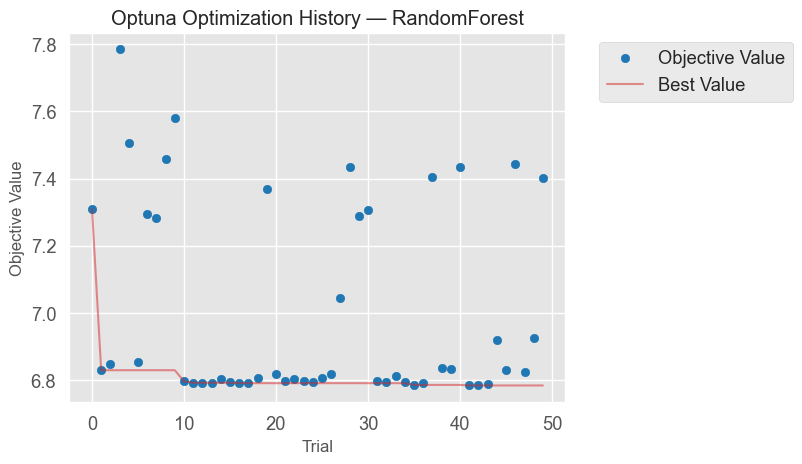

In [46]:
from optuna.visualization.matplotlib import plot_optimization_history

if best_study is None:
    print("⚠️ no Optuna Tuning record")
else:
    plt.figure(figsize=(16,5))
    plot_optimization_history(best_study)
    plt.title(f"Optuna Optimization History — {best_model_name}")
    plt.show()


### 4.3 Featrue importance

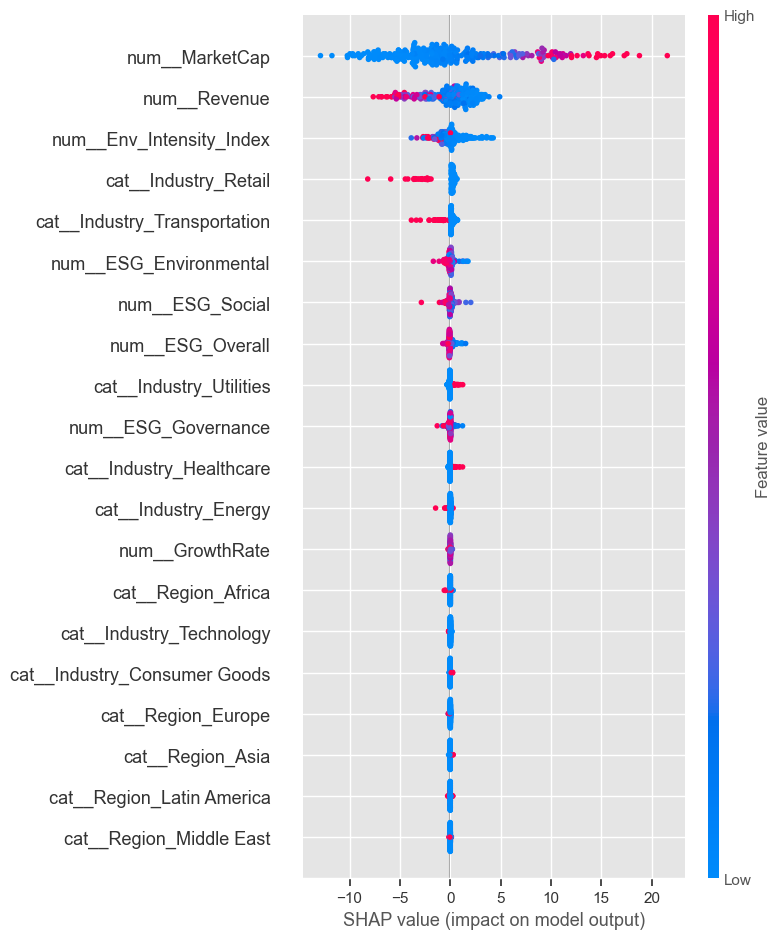

In [47]:
X_sample = X_raw.sample(300, random_state=42)

try:
    reg = best_model.named_steps["regressor"]
    X_trans = best_model.named_steps["preprocessor"].transform(X_sample)
    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
except:
    reg = best_model
    X_trans = X_sample
    feature_names = X_raw.columns

is_tree = any(keyword in str(type(reg)) for keyword in [
    "XGB", "LGBM", "CatBoost", "Forest", "Tree", "GradientBoosting"
])

if is_tree:
    explainer = shap.TreeExplainer(reg)
    shap_values = explainer(X_trans)
else:
    print("⚠️ 非 tree 模型，使用 KernelExplainer（較慢）")
    explainer = shap.KernelExplainer(reg.predict, X_trans[:50])
    shap_values = explainer.shap_values(X_trans[:200])

# --- Summary Plot ---
shap.summary_plot(shap_values, X_trans, feature_names=feature_names, show=True)


## 5. Strategy

In [48]:
# ================================================================
# 1. USER INPUT SYSTEM
# ================================================================

def convert_user_threshold(user_score):
    """Convert scale 1–10 → percentile 0.10–0.90."""
    return 0.1 + (user_score - 1) * (0.8 / 9)


def ask_sustainability_dimension():
    print("\n🌱 Which sustainability dimension do you want to focus on?\n")
    print("1. ESG Overall Score")
    print("2. ESG Environmental Score")
    print("3. ESG Social Score")
    print("4. ESG Governance Score")

    mapping = {
        1: "ESG_Overall",
        2: "ESG_Environmental",
        3: "ESG_Social",
        4: "ESG_Governance",
    }

    while True:
        try:
            choice = int(input("\nSelect a number (1–4): → "))
            if 1 <= choice <= 4:
                return mapping[choice]
            else:
                print("❗ Please enter a number between 1 and 4.")
        except:
            print("❗ Invalid input. Please enter a number between 1 and 4.")


def ask_user_preference():
    print("\n🌱 Sustainability Priority Level (1–10)")
    print("1  = I prioritize profit only")
    print("10 = I want the strongest sustainability performance")

    while True:
        try:
            score = int(input("\nHow much do you care (1–10)? → "))
            if 1 <= score <= 10:
                return score
            else:
                print("❗ Please enter a number between 1 and 10.")
        except:
            print("❗ Invalid input. Enter a number between 1 and 10.")


# ================================================================
# 2. PORTFOLIO FILTER + OPTIMIZATION
# ================================================================

def filter_by_environment(df, user_score, e_col):
    percentile = convert_user_threshold(user_score)

    # If lower is better → invert threshold
    if e_col in ["CarbonEmissions", "EnergyConsumption", "WaterUsage"]:
        threshold_value = df[e_col].quantile(1 - percentile)
        df_filtered = df[df[e_col] <= threshold_value].copy()
    else:
        threshold_value = df[e_col].quantile(percentile)
        df_filtered = df[df[e_col] >= threshold_value].copy()

    return df_filtered, threshold_value


def build_portfolio(df, user_score, e_col, top_n=3, alpha=0.4, beta=0.6):

    df_filtered, threshold_value = filter_by_environment(df, user_score, e_col)
    df_filtered = df_filtered.copy()

    print(f"\n🌱 Focusing on: {e_col}")
    print(f"📊 Threshold applied: {threshold_value:.2f}")
    print(f"📉 Companies remaining: {len(df_filtered)} / {len(df)}")

    if len(df_filtered) == 0:
        print("❗ No companies meet this sustainability threshold.")
        return pd.DataFrame()

    # Safe normalization for predicted profit
    pmin, pmax = df_filtered["predicted_profit"].min(), df_filtered["predicted_profit"].max()
    prange = (pmax - pmin) if (pmax - pmin) != 0 else 1
    df_filtered["profit_norm"] = (df_filtered["predicted_profit"] - pmin) / prange

    # Safe normalization for sustainability dimension
    emin, emax = df_filtered[e_col].min(), df_filtered[e_col].max()
    erange = (emax - emin) if (emax - emin) != 0 else 1
    df_filtered["escore_norm"] = (df_filtered[e_col] - emin) / erange

    # Composite score
    df_filtered["portfolio_score"] = (
        alpha * df_filtered["profit_norm"] + beta * df_filtered["escore_norm"]
    )

    # Top N per industry
    portfolio = (
        df_filtered
        .sort_values(["Industry", "portfolio_score"], ascending=[True, False])
        .groupby("Industry")
        .head(top_n)
        .reset_index(drop=True)
    )

    return portfolio


# ================================================================
# 3. AGGREGATION — ONE ROW PER COMPANY (2016–2025 AVERAGE)
# ================================================================

def aggregate_company_data(df, company_ids, company_col="CompanyID"):
    """Return ONE row per company with averaged numeric values."""
    subset = df[df[company_col].isin(company_ids)].copy()

    # Identify numeric & categorical columns
    numeric_cols = subset.select_dtypes(include=["int64", "float64"]).columns
    categorical_cols = subset.select_dtypes(include=["object"]).columns

    # Remove CompanyID from numeric columns if present
    numeric_cols = numeric_cols.drop(company_col) if company_col in numeric_cols else numeric_cols

    # Group numeric → mean
    df_numeric = subset.groupby(company_col)[numeric_cols].mean()

    # Group categorical → mode
    df_categorical = subset.groupby(company_col)[categorical_cols].agg(lambda x: x.mode().iloc[0])

    # Merge back
    df_final = df_numeric.merge(df_categorical, left_index=True, right_index=True)

    # Prevent inserting CompanyID twice
    return df_final.reset_index(drop=False)



# ================================================================
# 4. RUN PIPELINE
# ================================================================

# Add predictions to dataset
df_final["predicted_profit"] = best_model.predict(X_raw)

# Step 1: Ask sustainability dimension
chosen_dimension = ask_sustainability_dimension()

# Step 2: Ask sustainability strength
user_score = ask_user_preference()

# Step 3: Build portfolio (raw rows)
portfolio_raw = build_portfolio(
    df_final,
    user_score=user_score,
    e_col=chosen_dimension,
    top_n=3
)

# Step 4: Collapse to one row per company
portfolio_final = aggregate_company_data(df_final, portfolio_raw["CompanyID"])
portfolio_final = portfolio_final.drop(columns=['Year', 'CompanyName'])

print("\n🎯 Recommended Portfolio (Averaged 2016–2025):")
display(portfolio_final)


🌱 Which sustainability dimension do you want to focus on?

1. ESG Overall Score
2. ESG Environmental Score
3. ESG Social Score
4. ESG Governance Score

🌱 Sustainability Priority Level (1–10)
1  = I prioritize profit only
10 = I want the strongest sustainability performance

🌱 Focusing on: ESG_Social
📊 Threshold applied: 52.30
📉 Companies remaining: 5445 / 10000

🎯 Recommended Portfolio (Averaged 2016–2025):


,CompanyID,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,Env_Intensity_Index,predicted_profit,Industry,Region
0,36,2272.49,24.56,10433.08,7.68,75.57,37.62,98.98,90.12,2.826894e+05,20.919675,Healthcare,Europe
1,106,2536.29,13.93,5938.70,7.12,68.09,7.44,97.60,99.25,5.511142e+06,9.168889,Manufacturing,Europe
2,157,5136.19,17.65,17160.78,3.44,91.24,91.20,95.54,87.00,1.387571e+06,15.181644,Consumer Goods,Europe
3,210,1163.66,4.25,904.19,1.32,91.32,85.91,95.47,92.58,8.116073e+04,4.395004,Retail,Oceania
4,276,998.61,0.02,2168.17,3.36,49.87,13.45,97.16,39.06,9.937524e+05,3.576061,Transportation,North America
5,329,21411.86,27.41,80327.20,5.28,84.39,76.11,96.52,80.47,3.804846e+05,22.456725,Finance,Oceania
6,378,1870.80,31.13,17782.13,7.07,91.13,86.89,97.11,89.42,6.600157e+04,27.639013,Technology,Oceania
7,380,581.64,6.45,661.83,6.55,90.81,85.12,94.86,92.40,4.069305e+04,6.077526,Retail,Europe
8,595,3182.14,23.65,14885.49,5.71,80.80,63.96,92.67,85.74,1.151452e+06,19.203421,Consumer Goods,Oceania
9,637,809.03,12.95,1243.79,8.61,54.88,26.94,97.84,39.91,2.518009e+06,11.011777,Utilities,Oceania
